# Week 2 — House Fundamentals Model

Train an XGBoost regressor on 2010–2020 historical House race data, backtest against 2022, and benchmark against 538.

**Features:** `partisan_lean`, `gdp_growth_q2`, `unemp_oct`, `log_gdp_growth`, `midterm_year`, `redistricted`, `incumbent_party`, `dem_share_prev`  
**Target:** `dem_share` (two-party Democratic vote share, 0–1)

In [5]:
import pandas as pd 
import numpy as np
import os
import xgboost as xgb 
from sklearn.metrics import mean_squared_error

df = pd.read_csv(os.path.expanduser('~/Documents/2026MLpredictor/data/processed/house_week1_merged.csv'), low_memory=False) 
print(df.shape) 
print(df.columns.tolist())

df = df[df['uncontested'] == False]

approval = pd.read_csv(os.path.expanduser('~/Documents/2026MLpredictor/data/raw/pres_approval.csv'))
df = df.merge(approval[['year', 'pres_approval']], on='year', how='left')
print(f"After approval merge: {df.shape}, NaNs in pres_approval: {df['pres_approval'].isna().sum()}", flush=True)

(3046, 16)
['year', 'state_po', 'district', 'dem_votes', 'other_votes', 'rep_votes', 'dem_share', 'uncontested', 'partisan_lean', 'gdp_growth_q2', 'unemp_oct', 'log_gdp_growth', 'midterm_year', 'redistricted', 'dem_share_prev', 'incumbent_party']
After approval merge: (2723, 17), NaNs in pres_approval: 0


In [6]:
df.value_counts()

year  state_po  district  dem_votes  other_votes  rep_votes  dem_share  uncontested  partisan_lean  gdp_growth_q2  unemp_oct  log_gdp_growth  midterm_year  redistricted  dem_share_prev  incumbent_party  pres_approval
2012  AK        0         82927      20617        185296     0.309172   False        -15.21000       1.8           7.8         1.029619       0             0             0.306755        -1               50.8             1
2020  CO        4         173945     15556        285606     0.378511   False        -26.96000      -28.0          6.9        -3.367296       0             0             0.393807        -1               43.3             1
                2         316925     16191        182547     0.634520   False         15.13000      -28.0          6.9        -3.367296       0             0             0.641785         1               43.3             1
                1         331621     12714        105955     0.757859   False         39.00000      -28.0          6.

## Train / Test Split — Holdout Validation

**Intuition.** To honestly evaluate a model, you must test it on data it never saw during training. Normally this is a random 80/20 split. Here it must be *time-based*: if any 2022 data leaked into training, the model would be cheating — it would have seen the answer.

We train on **2010–2020** (6 election cycles) and hold out **2022** entirely. This simulates what the model would have actually known before the election.

No formula — this is a design decision. The key principle: the test set must be strictly in the future relative to all training data.

**Code:** `train = df[df['year'] <= 2020]` and `test = df[df['year'] == 2022]`

In [7]:
FEATURES = ['partisan_lean', 'gdp_growth_q2', 'unemp_oct', 'log_gdp_growth',
            'midterm_year', 'redistricted', 'incumbent_party', 'dem_share_prev',
            'pres_approval']
train = df[df['year'] <= 2020]
test  = df[df['year'] == 2022]
print(train.shape, test.shape)

(2323, 17) (400, 17)


## Loss Function and Gradient Boosting

### Mean Squared Error (the loss function)

**Intuition.** Training requires a single number measuring "how wrong is the model overall," differentiable so calculus can minimize it.

$$L = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

- $n$ = number of districts in the training set  
- $y_i$ = actual `dem_share` for district $i$  
- $\hat{y}_i$ = model's predicted `dem_share` for district $i$

**Why squared, not absolute value?** $|x|$ has a sharp corner at 0 and is not differentiable there — gradient-based optimization breaks. $x^2$ is smooth everywhere. Squaring also penalizes large errors quadratically: a 20-point miss costs 4× more than a 10-point miss, not 2×.

---

### Gradient Boosting

**Intuition.** One decision tree is too simple. Build trees sequentially where each new tree's job is to correct the *residuals* (mistakes) of all previous trees combined.

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

- $F_{m-1}(x)$ = combined prediction of all trees built so far  
- $h_m(x)$ = new tree trained to predict the negative gradient of $L$ at $F_{m-1}$; for squared-error loss this simplifies to the residuals $y - F_{m-1}(x)$  
- $\eta$ = learning rate — how much weight the new tree gets

**Why a small $\eta$?** With $\eta = 1$ each tree overcompensates and the model oscillates. $\eta = 0.05$ means each tree nudges predictions only 5%, forcing 300 small careful steps instead of a few aggressive, brittle ones.

**Code:** `n_estimators=300` = number of trees; `learning_rate=0.05` = $\eta$; `model.fit(X_train, y_train)` runs the full loop.

In [8]:
X_train = train[FEATURES]
y_train = train['dem_share']
X_test = test[FEATURES]
y_test = test['dem_share']
model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## RMSE — Root Mean Squared Error

**Intuition.** MSE is in squared vote-share units — not human-readable. Take the square root to return to original units.

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

**Why the square root?** It exactly undoes the squaring from MSE, putting the error back in vote-share units. RMSE = 0.052 means predictions are off by **5.2 percentage points on average** — directly interpretable.

**Code:** `np.sqrt(mean_squared_error(y_test, preds))` — sklearn computes the inner sum, `np.sqrt` applies $\sqrt{\cdot}$.

In [9]:
preds = model.predict(X_test)
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"RMSE: {rmse:.4f}")


RMSE: 0.0520


## Converting Vote Share → Win Probability (Normal CDF)

**Intuition.** The model outputs a point estimate (e.g. 52% predicted Democratic). The Brier Score needs a *probability of winning*, not a vote share. We assume prediction errors are normally distributed around our estimate with spread = RMSE, then ask: what fraction of that bell curve lies above 50%?

$$P(\text{Dem wins}) = \Phi\!\left(\frac{\hat{y} - 0.5}{\sigma}\right)$$

where $\Phi(z) = \displaystyle\int_{-\infty}^{z} \frac{1}{\sqrt{2\pi}}\, e^{-t^2/2}\,dt$

- $\hat{y}$ = predicted vote share  
- $\sigma$ = RMSE (assumed standard deviation of our prediction error)  
- $\Phi$ = cumulative normal distribution — the area under the bell curve up to $z$

**Why normal?** By the Central Limit Theorem, many small independent error sources sum to approximately normal. It's the simplest defensible default.

**Code:** `norm.cdf((preds - 0.5) / rmse)` — the argument standardizes how many $\sigma$ our prediction sits above the 50% threshold; `norm.cdf` integrates the standard normal up to that point.

In [10]:
from scipy.stats import norm 
prob_dem = norm.cdf((preds-0.5) / rmse)
prob_dem[:5]

array([3.03906242e-01, 1.29068075e-03, 5.13971677e-04, 6.35932840e-09,
       1.10781619e-03])

## Brier Score

**Intuition.** RMSE measures vote-share error. Brier Score measures *probabilistic accuracy* — penalizing both wrong predictions and overconfident wrong ones.

$$BS = \frac{1}{n}\sum_{i=1}^{n}(p_i - o_i)^2$$

- $p_i$ = predicted probability district $i$ goes Democratic (0–1)  
- $o_i$ = actual outcome: 1 if Democrats won, 0 if Republicans won  
- Lower is better: perfect = 0, random guessing ≈ 0.25

**Why squared?** This makes Brier Score a *proper scoring rule* — the optimal strategy is to report your true honest probability. Claiming 99% confidence when you're uncertain gets punished hard if wrong: $(0.99 - 0)^2 = 0.98$.

**Code:** `np.mean((prob_dem - actual_win) ** 2)` — `prob_dem` is $p_i$ from the CDF step; `actual_win` is $o_i$ (binary 0/1).

In [11]:
actual_win = (y_test.values > 0.5).astype(float)
brier = np.mean((prob_dem - actual_win) ** 2)
print(f"Brier Score: {brier:.4f}")

Brier Score: 0.0600


## SHAP Values — Explaining Individual Predictions

**Intuition.** XGBoost is a black box: features go in, a prediction comes out. SHAP opens the box. For each district it answers: *how much did each feature contribute to pushing this prediction above or below the baseline?* The idea comes from cooperative game theory — features are "players" collaborating to produce a prediction, and SHAP distributes credit fairly among them.

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\Big[f(S \cup \{i\}) - f(S)\Big]$$

- $F$ = full set of 8 features; $S$ = a subset not including feature $i$  
- $f(S)$ = model's expected prediction using only features in $S$  
- $f(S \cup \{i\}) - f(S)$ = marginal contribution of feature $i$ when added to coalition $S$  
- The weighting term averages across every possible ordering in which features could join

**Key property:** $\sum_i \phi_i = \hat{y} - \mathbb{E}[\hat{y}]$ — SHAP values always sum exactly to the gap between this prediction and the global average. No unexplained residual.

**Why this formula?** It is the *unique* solution satisfying four game-theory fairness axioms (efficiency, symmetry, dummy, additivity). Not arbitrary.

**Code:** `shap.TreeExplainer(model)` uses a fast exact algorithm for tree ensembles (polynomial time). `explainer(X_test)` computes $\phi_i$ for every feature × every district.

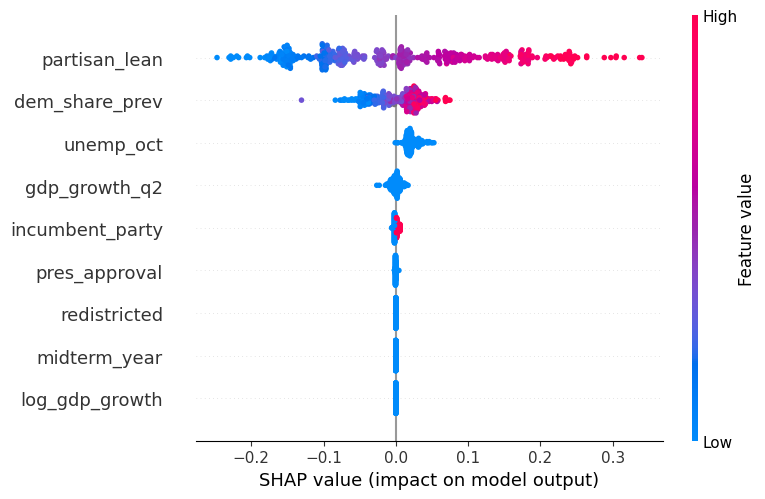

In [12]:
import shap 

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


## Reading the SHAP Summary Plot

Each dot = one district. The summary plot packs three dimensions:

- **Y-axis** — features ranked by importance (mean $|\phi_i|$ across all districts)
- **X-axis** — the SHAP value $\phi_i$: positive = pushed this district's prediction more Democratic; negative = more Republican
- **Color** — red = high feature value, blue = low feature value

Expected pattern for `partisan_lean`: red dots (strongly D districts) should cluster on the right; blue dots (strongly R) on the left. If you see this, the model learned what we'd expect from political science.

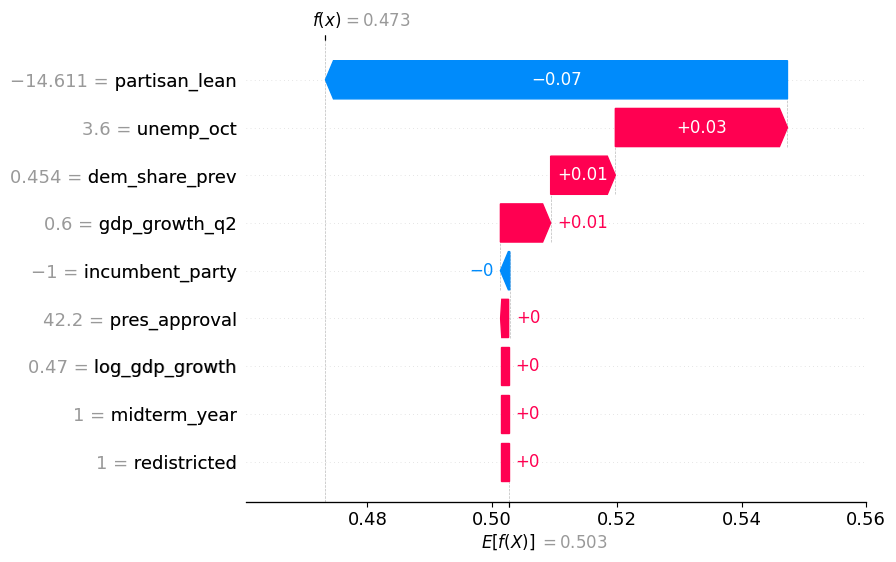

In [13]:
shap.plots.waterfall(shap_values[0])


## 538 Benchmark — Comparing Our Model vs. 538 Classic (2022)

We downloaded 538's final pre-election forecast (November 8, 2022 — election day) from their archived data. Model used: "classic" (polls + fundamentals + expert ratings).

To merge, we construct a `match_key` like `AL-1` from our `state_po` and `district` columns, matching 538's format. At-large states (AK, DE, etc.) use district 1 in 538 but district 0 in our MIT data — we remap before merging.

No new formula — RMSE and Brier Score formulas are the same as above, applied to 538's predictions instead of ours.

In [14]:
AT_LARGE = ['AK', 'DE', 'MT', 'ND', 'SD', 'VT', 'WY']
test = test.copy()
test['district_fixed'] = test.apply(
    lambda row: 1 if row['state_po'] in AT_LARGE else row['district'], axis=1
)
test['match_key'] = test['state_po'] + '-' + test['district_fixed'].astype(str)

In [15]:
fte = pd.read_csv('../data/raw/fte_2022_house_forecast.csv')
test = test.merge(fte, left_on='match_key', right_on='district', how='left', suffixes=('', '_fte'))
print(test['fte_winner_dem_prob'].isna().sum())

0


In [16]:
test['fte_voteshare_dem'] = test['fte_voteshare_dem'].astype(float) / 100
test['fte_winner_dem_prob'] = test['fte_winner_dem_prob'].astype(float)

fte_rmse = np.sqrt(mean_squared_error(test['dem_share'], test['fte_voteshare_dem']))
fte_brier = np.mean((test['fte_winner_dem_prob'] - actual_win) ** 2)

print(f"Our RMSE:   {rmse:.4f}   |   538 RMSE:   {fte_rmse:.4f}")
print(f"Our Brier:  {brier:.4f}   |   538 Brier:  {fte_brier:.4f}")

Our RMSE:   0.0520   |   538 RMSE:   0.0351
Our Brier:  0.0600   |   538 Brier:  0.0338


## Multi-Cycle Backtest — Expanding Window Validation

**Intuition.** One backtest on 2022 tells us how the model did on one election. That could be luck. Testing on 2018, 2020, and 2022 independently gives three separate readings — if the model is consistently decent across all three, that's a real signal.

**Why expanding window?**  
Each test uses all data available *before* that election — nothing from after. So the 2018 test trains on 2010–2016 only. The 2020 test trains on 2010–2018. The 2022 test trains on 2010–2020. The window grows each cycle because a real forecaster would use everything historically known, not throw away older elections.

| Test year | Training data | What was known |
|-----------|--------------|----------------|
| 2018 | 2010–2016 | 4 cycles |
| 2020 | 2010–2018 | 5 cycles |
| 2022 | 2010–2020 | 6 cycles |

**No new formula** — RMSE and Brier Score are identical to the cells above, computed fresh for each split.

**Code structure:** loop over `[(2018, 2016), (2020, 2018), (2022, 2020)]` — each tuple is `(test_year, train_cutoff)`. Inside the loop: subset `df`, retrain the model from scratch, compute RMSE and Brier, append to a results list. Print a summary table at the end.

In [17]:
results = []

for test_year, train_cutoff in [(2018, 2016), (2020, 2018), (2022, 2020)]:
    tr = df[df['year'] <= train_cutoff]
    te = df[df['year'] == test_year]

    m = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
    m.fit(tr[FEATURES], tr['dem_share'])

    p = m.predict(te[FEATURES])
    r = np.sqrt(mean_squared_error(te['dem_share'], p))
    win_prob = norm.cdf((p - 0.5) / r)
    actual = (te['dem_share'].values > 0.5).astype(float)
    b = np.mean((win_prob - actual) ** 2)

    results.append({'year': test_year, 'our_rmse': r, 'our_brier': b})
    print(f"{test_year}  RMSE={r:.4f}  Brier={b:.4f}", flush=True)

print()
print(pd.DataFrame(results).to_string(index=False))

2018  RMSE=0.0625  Brier=0.0915
2020  RMSE=0.0382  Brier=0.0323
2022  RMSE=0.0520  Brier=0.0600

 year  our_rmse  our_brier
 2018  0.062465   0.091501
 2020  0.038175   0.032276
 2022  0.052049   0.060028


## Multi-Cycle Benchmark — Our Model vs. 538

Same expanding-window loop, but now we also load 538's archived forecast for each year and compute their RMSE and Brier Score side by side.

**538 data sources (all classic model, election-day snapshot):**
- 2018: `projects.fivethirtyeight.com/congress-model-2018/house_district_forecast.csv` (Nov 5, 2018)
- 2020: `projects.fivethirtyeight.com/2020-general-data/house_district_toplines_2020.csv` (Nov 3, 2020)
- 2022: `projects.fivethirtyeight.com/2022-general-election-forecast-data/house_district_toplines_2022.csv` (Nov 8, 2022)

At-large states (AK, DE, MT, ND, SD, VT, WY) use district 1 in 538 but district 0 in MIT data — remapped via `match_key` before merging.

In [18]:
AT_LARGE = ['AK', 'DE', 'MT', 'ND', 'SD', 'VT', 'WY']

fte_files = {
    2018: os.path.expanduser('~/Documents/2026MLpredictor/data/raw/fte_2018_house_forecast.csv'),
    2020: os.path.expanduser('~/Documents/2026MLpredictor/data/raw/fte_2020_house_forecast.csv'),
    2022: os.path.expanduser('~/Documents/2026MLpredictor/data/raw/fte_2022_house_forecast.csv'),
}

comparison = []

for test_year, train_cutoff in [(2018, 2016), (2020, 2018), (2022, 2020)]:
    tr = df[df['year'] <= train_cutoff]
    te = df[df['year'] == test_year].copy()

    m = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
    m.fit(tr[FEATURES], tr['dem_share'])

    p = m.predict(te[FEATURES])
    r = np.sqrt(mean_squared_error(te['dem_share'], p))
    win_prob = norm.cdf((p - 0.5) / r)
    actual = (te['dem_share'].values > 0.5).astype(float)
    our_b = np.mean((win_prob - actual) ** 2)

    te['district_fixed'] = te.apply(
        lambda row: 1 if row['state_po'] in AT_LARGE else row['district'], axis=1
    )
    te['match_key'] = te['state_po'] + '-' + te['district_fixed'].astype(str)

    fte = pd.read_csv(fte_files[test_year])
    te_merged = te.merge(fte, left_on='match_key', right_on='district', how='inner')

    fte_vs = te_merged['fte_voteshare_dem'].astype(float)
    if fte_vs.max() > 1:
        fte_vs = fte_vs / 100

    actual_fte = (te_merged['dem_share'].values > 0.5).astype(float)
    fte_r = np.sqrt(mean_squared_error(te_merged['dem_share'], fte_vs))
    fte_b = np.mean((te_merged['fte_winner_dem_prob'].astype(float) - actual_fte) ** 2)

    comparison.append({
        'year': test_year, 'n': len(te_merged),
        'our_rmse': r, 'fte_rmse': fte_r,
        'our_brier': our_b, 'fte_brier': fte_b,
    })
    print(f"{test_year}  Our RMSE={r:.4f} Brier={our_b:.4f}  |  538 RMSE={fte_r:.4f} Brier={fte_b:.4f}  (n={len(te_merged)})", flush=True)

print()
cdf = pd.DataFrame(comparison)[['year', 'our_rmse', 'fte_rmse', 'our_brier', 'fte_brier']]
print(cdf.to_string(index=False))

2018  Our RMSE=0.0625 Brier=0.0915  |  538 RMSE=0.0334 Brier=0.0295  (n=393)
2020  Our RMSE=0.0382 Brier=0.0323  |  538 RMSE=0.0339 Brier=0.0344  (n=407)
2022  Our RMSE=0.0520 Brier=0.0600  |  538 RMSE=0.0351 Brier=0.0338  (n=400)

 year  our_rmse  fte_rmse  our_brier  fte_brier
 2018  0.062465  0.033364   0.091501   0.029493
 2020  0.038175  0.033941   0.032276   0.034381
 2022  0.052049  0.035086   0.060028   0.033812


## Save Final Model

The backtest used expanding windows — each test trained on a subset. Now we train one final model on **all available data (2010–2022)** and save it. This is the model that will generate 2026 predictions.

No formula — this is just the same `model.fit()` call using the full `df` instead of a cutoff subset, then serialized to disk via XGBoost's native JSON format.

In [19]:
final_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
final_model.fit(df[FEATURES], df['dem_share'])

os.makedirs(os.path.expanduser('~/Documents/2026MLpredictor/models'), exist_ok=True)
final_model.save_model(os.path.expanduser('~/Documents/2026MLpredictor/models/house_fundamentals.json'))
print("Saved.", flush=True)

Saved.


In [20]:
from fredapi import Fred 

FRED_KEY = '727f092728349011fc205b14d5f57ff3'
fred = Fred(api_key=FRED_KEY)
##q1 2026 GDP growth 
gdp = fred.get_series('A191RL1Q225SBEA')
gdp_2026_q1 = gdp['2026-01-01': '2026-03-31'].iloc[-1]

unemp = fred.get_series('UNRATE')
unemp_latest = gdp['2026-01-01': '2026-03-31'].iloc[-1]

unemp = fred.get_series('UNRATE')
unemp_latest = unemp['2026-01-01':].iloc[-1]

log_gdp = np.log(gdp_2026_q1) if gdp_2026_q1> 0 else -np.log(-gdp_2026_q1)


print(f"GDP Q1 2026: {gdp_2026_q1}", flush=True)
print(f"Unemployment (latest): {unemp_latest}", flush=True)
print(f"log_gdp_growth: {log_gdp:.4f}", flush=True)


GDP Q1 2026: 2.1
Unemployment (latest): 4.2
log_gdp_growth: 0.7419


In [21]:
TRUMP_APPROVAL = 41.0

econ_2026 = { 
    'year': 2026, 
    'gdp_growth_q2': gdp_2026_q1,
    'unemp_oct' : unemp_latest, 
    'log_gdp_growth' : log_gdp, 
    'pres_approval': TRUMP_APPROVAL
}

pd.DataFrame([econ_2026]).to_csv( os.path.expanduser('~/Documents/2026MLpredictor/data/raw/econ_2026.csv'),
    index=False)

print('Saved.', flush=True)

Saved.


In [22]:
import requests, io

r = requests.get(
    'https://en.wikipedia.org/wiki/Cook_Partisan_Voting_Index',
    headers={'User-Agent': 'Mozilla/5.0'}
)
pvi_tables = pd.read_html(io.StringIO(r.text))
for i, t in enumerate(pvi_tables):
    print(i, t.shape, t.columns.tolist()[:4])


0 (435, 3) ['District', 'PVI', 'Party of representative']
1 (51, 6) ['State', 'PVI', 'Last presidential election winner', 'Party of governor']
2 (49, 2) ['vteUnited States Congress', 'vteUnited States Congress.1']
3 (16, 2) ['Members and leaders', 'Members and leaders.1']
4 (15, 2) [0, 1]
5 (3, 2) [0, 1]
6 (2, 2) [0, 1]
7 (5, 2) [0, 1]
8 (10, 2) ['Powers, privileges, procedure, committees, history, media', 'Powers, privileges, procedure, committees, history, media.1']
9 (9, 2) [0, 1]
10 (1, 2) [0, 1]
11 (16, 2) ['Capitol Complex on Capitol Hill and other headquarters offices', 'Capitol Complex on Capitol Hill and other headquarters offices.1']
12 (15, 2) [0, 1]
13 (2, 2) [0, 1]
14 (2, 2) [0, 1]
15 (2, 2) [0, 1]


In [23]:
pvi_raw = pvi_tables[0][['District', 'PVI']].copy()
print(pvi_raw.head(10))
print(pvi_raw['PVI'].unique()[:10])


          District   PVI
0        Alabama 1  R+27
1        Alabama 2   D+5
2        Alabama 3  R+23
3        Alabama 4  R+33
4        Alabama 5  R+15
5        Alabama 6  R+20
6        Alabama 7  D+13
7  Alaska at-large   R+6
8        Arizona 1   R+1
9        Arizona 2   R+7
['R+27' 'D+5' 'R+23' 'R+33' 'R+15' 'R+20' 'D+13' 'R+6' 'R+1' 'R+7']


In [24]:
state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA',
    'Michigan':'MI','Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT',
    'Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND',
    'Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI',
    'South Carolina':'SC','South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
    'Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
    'Wisconsin':'WI','Wyoming':'WY'
}

def parse_district(d):
    parts = d.split()
    last = parts[-1]
    state_name = ' '.join(parts[:-1])
    district = 0 if last.lower() == 'at-large' else int(last)
    return state_abbrev[state_name], district

def parse_pvi(pvi):
    if pvi == 'EVEN':
        return 0.0
    direction = 1 if pvi.startswith('D') else -1
    return direction * float(pvi.split('+')[1])

pvi_raw[['state_po','district']] = pvi_raw['District'].apply(
    lambda x: pd.Series(parse_district(x))
)
pvi_raw['partisan_lean'] = pvi_raw['PVI'].apply(parse_pvi)
pvi_clean = pvi_raw[['state_po','district','partisan_lean']].copy()

print(pvi_clean.shape)
print(pvi_clean.head(8))

(435, 3)
  state_po  district  partisan_lean
0       AL         1          -27.0
1       AL         2            5.0
2       AL         3          -23.0
3       AL         4          -33.0
4       AL         5          -15.0
5       AL         6          -20.0
6       AL         7           13.0
7       AK         0           -6.0


In [25]:
pvi_clean.to_csv(
    os.path.expanduser('~/Documents/2026MLpredictor/data/raw/pvi_119th.csv'),
    index=False
)
print(f"Saved {len(pvi_clean)} districts.", flush=True)

Saved 435 districts.


In [26]:
import requests, io

url = "https://raw.githubusercontent.com/MEDSL/2024-elections-official/main/subsets/2024-house-president.csv"
r = requests.get(url)
print(r.status_code)
results_2024 = pd.read_csv(io.StringIO(r.text), low_memory=False)
print(results_2024.shape)
print(results_2024.columns.tolist())


404
(0, 1)
['404: Not Found']


In [27]:
url = "https://michaelminn.net/tutorials/data/2024-electoral-districts.csv"
r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
results_2024 = pd.read_csv(io.StringIO(r.text))
print(results_2024.shape)
print(results_2024.columns.tolist())
print(results_2024.head(3))


(441, 13)
['GEOIDFQ', 'ST', 'Name', 'Square_Miles', 'Latitude', 'Longitude', 'Winner_2024', 'Votes_Dem_2024', 'Percent_Dem_2024', 'Votes_GOP_2024', 'Percent_GOP_2024', 'Votes_Other_2024', 'Percent_Other_2024']
         GEOIDFQ  ST  Name  Square_Miles  Latitude  Longitude  \
0  5001900US0101  AL  AL-1          7241     31.03     -86.79   
1  5001900US0102  AL  AL-2          9465     31.76     -86.63   
2  5001900US0103  AL  AL-3          6690     33.41     -85.77   

       Winner_2024  Votes_Dem_2024  Percent_Dem_2024  Votes_GOP_2024  \
0      Barry Moore         70929.0             21.50        258619.0   
1  Shomari Figures        158041.0             54.56        131414.0   
2      Mike Rogers             NaN               NaN        243848.0   

   Percent_GOP_2024  Votes_Other_2024  Percent_Other_2024  
0             78.40             306.0                0.09  
1             45.37             219.0                0.08  
2             97.93            5160.0                2.07  


In [28]:
# parse state and district from Name (e.g. "AL-1", "AK-0")
results_2024['state_po'] = results_2024['Name'].str.split('-').str[0]
results_2024['district_raw'] = results_2024['Name'].str.split('-').str[1]

# at-large districts appear as "AK-AL" or similar — map to 0
results_2024['district'] = results_2024['district_raw'].apply(
    lambda x: 0 if not str(x).isdigit() else int(x)
)

# two-party dem share — NaN dem votes means uncontested Republican, set to 0
results_2024['dem_votes'] = results_2024['Votes_Dem_2024'].fillna(0)
results_2024['rep_votes'] = results_2024['Votes_GOP_2024'].fillna(0)
total = results_2024['dem_votes'] + results_2024['rep_votes']
results_2024['dem_share_prev'] = (results_2024['dem_votes'] / total).fillna(0)

share_2024 = results_2024[['state_po', 'district', 'dem_share_prev']].copy()
print(share_2024.shape)
print(share_2024.head(8))
print(f"\nAt-large districts: {share_2024[share_2024['district']==0]}")

(441, 3)
  state_po  district  dem_share_prev
0       AL         1        0.215231
1       AL         2        0.545995
2       AL         3        0.000000
3       AL         4        0.000000
4       AL         5        0.000000
5       AL         6        0.296045
6       AL         7        0.637204
7       AK         0        0.489241

At-large districts:     state_po  district  dem_share_prev
7         AK         0        0.489241
86        DE         0        0.578627
87        DC         0        0.927148
298       ND         0        0.304832
351       SD         0        0.279555
403       VT         0        0.676471
435       WY         0        0.247611
436       AS         0        0.199264
437       GU         0        0.470342
438       MP         0        0.451989
439       PR         0        0.559888
440       VI         0        0.885228


In [29]:
VALID_STATES = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
    'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
    'VA','WA','WV','WI','WY'
]

results_2024['state_po'] = results_2024['Name'].str.split('-').str[0]
results_2024['district_raw'] = results_2024['Name'].str.split('-').str[1]
results_2024['district'] = results_2024['district_raw'].apply(
    lambda x: 0 if not str(x).isdigit() else int(x)
)
results_2024 = results_2024[results_2024['state_po'].isin(VALID_STATES)].copy()

dem = results_2024['Votes_Dem_2024'].fillna(0)
rep = results_2024['Votes_GOP_2024'].fillna(0)
results_2024['winner_party'] = (dem > rep).map({True: 1, False: -1})

print(results_2024[['Name','winner_party']].head(10))
print(results_2024['winner_party'].value_counts())

    Name  winner_party
0   AL-1            -1
1   AL-2             1
2   AL-3            -1
3   AL-4            -1
4   AL-5            -1
5   AL-6            -1
6   AL-7             1
7  AK-AL            -1
8   AZ-1            -1
9   AZ-2            -1
winner_party
-1    221
 1    214
Name: count, dtype: int64


In [30]:
incumbency_2026 = results_2024[['state_po', 'district', 'winner_party']].rename(
    columns={'winner_party': 'incumbent_party'}
).copy()

incumbency_2026.to_csv(
    os.path.expanduser('~/Documents/2026MLpredictor/data/raw/incumbency_2026.csv'),
    index=False
)
print(f"Saved {len(incumbency_2026)} districts.", flush=True)

Saved 435 districts.


In [31]:
# load all 2026 inputs
pvi       = pd.read_csv(os.path.expanduser('~/Documents/2026MLpredictor/data/raw/pvi_119th.csv'))
share_prev = pd.read_csv(os.path.expanduser('~/Documents/2026MLpredictor/data/raw/house_results_2024.csv'))
incumbency = pd.read_csv(os.path.expanduser('~/Documents/2026MLpredictor/data/raw/incumbency_2026.csv'))
econ      = pd.read_csv(os.path.expanduser('~/Documents/2026MLpredictor/data/raw/econ_2026.csv'))

# start from PVI (435 districts), merge everything in
feat = pvi.merge(share_prev, on=['state_po','district'], how='left')
feat = feat.merge(incumbency, on=['state_po','district'], how='left')

# economic features are national — same value for every district
feat['gdp_growth_q2'] = econ['gdp_growth_q2'].iloc[0]
feat['unemp_oct']     = econ['unemp_oct'].iloc[0]
feat['log_gdp_growth'] = econ['log_gdp_growth'].iloc[0]
feat['pres_approval'] = econ['pres_approval'].iloc[0]

# fixed features
feat['midterm_year'] = 1
feat['redistricted'] = 0

print(feat.shape)
print(feat[FEATURES].isna().sum())
print(feat[FEATURES].head())

(435, 11)
partisan_lean      0
gdp_growth_q2      0
unemp_oct          0
log_gdp_growth     0
midterm_year       0
redistricted       0
incumbent_party    0
dem_share_prev     0
pres_approval      0
dtype: int64
   partisan_lean  gdp_growth_q2  unemp_oct  log_gdp_growth  midterm_year  \
0          -27.0            2.1        4.2        0.741937             1   
1            5.0            2.1        4.2        0.741937             1   
2          -23.0            2.1        4.2        0.741937             1   
3          -33.0            2.1        4.2        0.741937             1   
4          -15.0            2.1        4.2        0.741937             1   

   redistricted  incumbent_party  dem_share_prev  pres_approval  
0             0               -1        0.215231           41.0  
1             0                1        0.545995           41.0  
2             0               -1        0.000000           41.0  
3             0               -1        0.000000           41.0  
4

In [32]:
from scipy.stats import norm

final_model = xgb.XGBRegressor()
final_model.load_model(os.path.expanduser('~/Documents/2026MLpredictor/models/house_fundamentals.json'))

preds_2026 = final_model.predict(feat[FEATURES])
sigma = 0.052  # RMSE from 2022 backtest

win_prob = norm.cdf((preds_2026 - 0.5) / sigma)

feat['pred_dem_share'] = preds_2026
feat['win_prob_dem']   = win_prob

print(feat[['state_po','district','pred_dem_share','win_prob_dem']].head(10))
print(f"\nProjected Dem seats: {(win_prob > 0.5).sum()}", flush=True)

  state_po  district  pred_dem_share  win_prob_dem
0       AL         1        0.365596      0.004873
1       AL         2        0.570536      0.912525
2       AL         3        0.338988      0.000979
3       AL         4        0.304945      0.000088
4       AL         5        0.365742      0.004913
5       AL         6        0.419206      0.060123
6       AL         7        0.627627      0.992943
7       AK         0        0.523848      0.676743
8       AZ         1        0.515059      0.613937
9       AZ         2        0.510492      0.579953

Projected Dem seats: 270


In [ ]:
import shap, json
import pandas as pd
import xgboost as xgb
import numpy as np
from scipy.stats import norm

final_model = xgb.XGBRegressor()
final_model.load_model(os.path.expanduser('~/Documents/2026MLpredictor/models/house_fundamentals.json'))

FEATURES = ['partisan_lean','gdp_growth_q2','unemp_oct','log_gdp_growth',
            'midterm_year','redistricted','incumbent_party','dem_share_prev','pres_approval']

preds = final_model.predict(feat[FEATURES])
sigma = 0.052
win_prob = norm.cdf((preds - 0.5) / sigma)

explainer = shap.TreeExplainer(final_model)
shap_vals = explainer.shap_values(feat[FEATURES])

hist = pd.read_csv(os.path.expanduser('~/Documents/2026MLpredictor/data/processed/house_week1_merged.csv'))
actual_2022 = hist[hist['year'] == 2022][['state_po', 'district', 'dem_share']].rename(columns={'dem_share': 'dem_share_2022'})

feat2 = feat.merge(actual_2022, on=['state_po', 'district'], how='left')
feat2['pred_dem_share'] = preds
feat2['win_prob_dem']   = win_prob

def rating(p):
    if p >= 0.85: return 'Safe D'
    if p >= 0.65: return 'Lean D'
    if p >= 0.35: return 'Toss-up'
    if p >= 0.15: return 'Lean R'
    return 'Safe R'

records = []
for i, row in feat2.iterrows():
    sv = shap_vals[i]
    top3_idx = np.argsort(np.abs(sv))[::-1][:3]
    shap_top3 = [{'feature': FEATURES[j], 'impact': round(float(sv[j]), 4)} for j in top3_idx]
    records.append({
        'state_po':       row['state_po'],
        'district':       int(row['district']),
        'pred_dem_share': round(float(row['pred_dem_share']), 4),
        'win_prob_dem':   round(float(row['win_prob_dem']), 4),
        'rating':         rating(row['win_prob_dem']),
        'dem_share_2024': round(float(row['dem_share_prev']), 4) if pd.notna(row.get('dem_share_prev')) else None,
        'dem_share_2022': round(float(row['dem_share_2022']), 4) if pd.notna(row.get('dem_share_2022')) else None,
        'shap':           shap_top3
    })

out_path = os.path.expanduser('~/Documents/2026MLpredictor/data/processed/predictions_2026.json')
with open(out_path, 'w') as f:
    json.dump(records, f, indent=2)
print(f"Exported {len(records)} districts to predictions_2026.json", flush=True)

In [34]:
feat.head()

,state_po,district,partisan_lean,dem_share_prev,incumbent_party,gdp_growth_q2,unemp_oct,log_gdp_growth,pres_approval,midterm_year,redistricted,pred_dem_share,win_prob_dem
0,AL,1,-27.0,0.215231,-1,2.1,4.2,0.741937,41.0,1,0,0.365596,0.004873
1,AL,2,5.0,0.545995,1,2.1,4.2,0.741937,41.0,1,0,0.570536,0.912525
2,AL,3,-23.0,0.000000,-1,2.1,4.2,0.741937,41.0,1,0,0.338988,0.000979
3,AL,4,-33.0,0.000000,-1,2.1,4.2,0.741937,41.0,1,0,0.304945,0.000088
4,AL,5,-15.0,0.000000,-1,2.1,4.2,0.741937,41.0,1,0,0.365742,0.004913
